In [1]:
import os
import math
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import cuda, njit, float32

IMAGE_PATH = "/content/img.jpg"
OUTPUT_DIR = "/content/lab10_results"

OMEGA = 3

BLOCK_SIZES = [(4, 4), (8, 8), (16, 16), (32, 8), (32, 16), (32, 32),]

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("CUDA available:", cuda.is_available())
print("Omega:", OMEGA)
print("Block sizes:", BLOCK_SIZES)

CUDA available: True
Omega: 3
Block sizes: [(4, 4), (8, 8), (16, 16), (32, 8), (32, 16), (32, 32)]


Image loaded successfully
Shape: (1920, 1080, 3)
Width: 1080
Height: 1920
HSV conversion completed
V range: 0.0 to 1.0


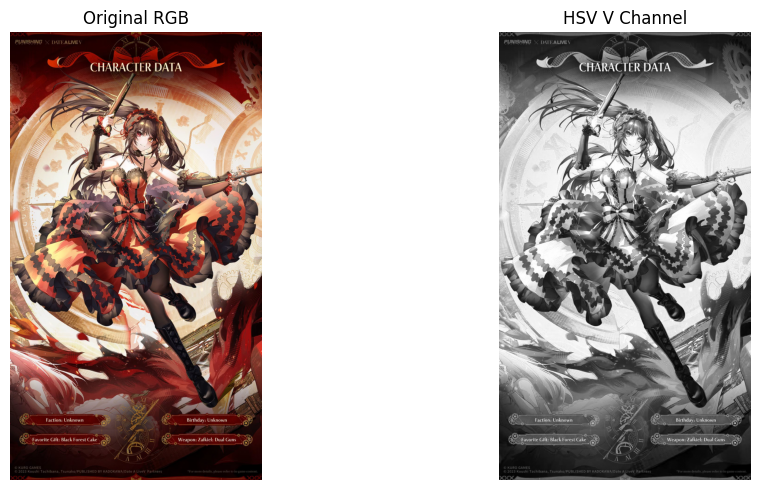

In [2]:
image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise FileNotFoundError(f"Cannot load image: {IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width, channels = image_rgb.shape

print("Image loaded successfully")
print("Shape:", image_rgb.shape)
print("Width:", width)
print("Height:", height)

hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

v_channel = hsv[:, :, 2].astype(np.float32) / 255.0

print("HSV conversion completed")
print("V range:", v_channel.min(), "to", v_channel.max())

cv2.imwrite(os.path.join(OUTPUT_DIR, "original.png"), cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))

cv2.imwrite(os.path.join(OUTPUT_DIR, "hsv_v.png"), (v_channel * 255).astype(np.uint8))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(v_channel, cmap="gray")
plt.title("HSV V Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
@njit
def kuwahara_cpu(image, v_channel, omega):
    height, width, _ = image.shape

    output = np.empty_like(image)

    for y in range(height):
        for x in range(width):

            best_std = 1e20

            best_r = 0.0
            best_g = 0.0
            best_b = 0.0

            for window in range(4):
                sum_v = 0.0
                sum_v2 = 0.0

                sum_r = 0.0
                sum_g = 0.0
                sum_b = 0.0

                count = 0

                if window == 0:
                    dy_start = -omega
                    dy_end = 0
                    dx_start = -omega
                    dx_end = 0

                elif window == 1:
                    dy_start = -omega
                    dy_end = 0
                    dx_start = 0
                    dx_end = omega

                elif window == 2:
                    dy_start = 0
                    dy_end = omega
                    dx_start = -omega
                    dx_end = 0

                else:
                    dy_start = 0
                    dy_end = omega
                    dx_start = 0
                    dx_end = omega

                for dy in range(dy_start, dy_end + 1):
                    for dx in range(dx_start, dx_end + 1):
                        yy = y + dy
                        xx = x + dx

                        if yy < 0:
                            yy = 0
                        elif yy >= height:
                            yy = height - 1

                        if xx < 0:
                            xx = 0
                        elif xx >= width:
                            xx = width - 1

                        v = float(v_channel[yy, xx])

                        r = float(image[yy, xx, 0])
                        g = float(image[yy, xx, 1])
                        b = float(image[yy, xx, 2])

                        sum_v += v
                        sum_v2 += v * v

                        sum_r += r
                        sum_g += g
                        sum_b += b

                        count += 1

                mean_v = sum_v / count

                variance = (sum_v2 / count) - (mean_v * mean_v)

                if variance < 0.0:
                    variance = 0.0

                std = math.sqrt(variance)

                if std < best_std:
                    best_std = std

                    best_r = sum_r / count
                    best_g = sum_g / count
                    best_b = sum_b / count

            output[y, x, 0] = int(best_r + 0.5)
            output[y, x, 1] = int(best_g + 0.5)
            output[y, x, 2] = int(best_b + 0.5)

    return output

print("Compiling CPU Kuwahara...")

cpu_warmup = kuwahara_cpu(image_rgb, v_channel, OMEGA)

print("CPU compilation completed.")

Compiling CPU Kuwahara...
CPU compilation completed.


In [4]:
@cuda.jit
def kuwahara_global_kernel(image, v_channel, output, omega):
    x, y = cuda.grid(2)

    height = image.shape[0]
    width = image.shape[1]

    if x >= width or y >= height:
        return

    best_std = 1e20

    best_r = 0.0
    best_g = 0.0
    best_b = 0.0

    for window in range(4):
        sum_v = 0.0
        sum_v2 = 0.0

        sum_r = 0.0
        sum_g = 0.0
        sum_b = 0.0

        count = 0

        if window == 0:
            dy_start = -omega
            dy_end = 0
            dx_start = -omega
            dx_end = 0

        elif window == 1:
            dy_start = -omega
            dy_end = 0
            dx_start = 0
            dx_end = omega

        elif window == 2:
            dy_start = 0
            dy_end = omega
            dx_start = -omega
            dx_end = 0

        else:
            dy_start = 0
            dy_end = omega
            dx_start = 0
            dx_end = omega

        for dy in range(dy_start, dy_end + 1):
            for dx in range(dx_start, dx_end + 1):
                yy = y + dy
                xx = x + dx

                if yy < 0:
                    yy = 0
                elif yy >= height:
                    yy = height - 1

                if xx < 0:
                    xx = 0
                elif xx >= width:
                    xx = width - 1

                v = v_channel[yy, xx]

                r = float(image[yy, xx, 0])
                g = float(image[yy, xx, 1])
                b = float(image[yy, xx, 2])

                sum_v += v
                sum_v2 += v * v

                sum_r += r
                sum_g += g
                sum_b += b

                count += 1

        mean_v = sum_v / count

        variance = (sum_v2 / count) - (mean_v * mean_v)

        if variance < 0.0:
            variance = 0.0

        std = math.sqrt(variance)

        if std < best_std:
            best_std = std

            best_r = sum_r / count
            best_g = sum_g / count
            best_b = sum_b / count

    output[y, x, 0] = int(best_r + 0.5)
    output[y, x, 1] = int(best_g + 0.5)
    output[y, x, 2] = int(best_b + 0.5)

In [5]:
MAX_BLOCK = 32
SHARED_SIZE = MAX_BLOCK + 2 * OMEGA

@cuda.jit
def kuwahara_shared_kernel(image, v_channel, output, omega):
    shared_r = cuda.shared.array(shape=(SHARED_SIZE, SHARED_SIZE), dtype=float32)
    shared_g = cuda.shared.array(shape=(SHARED_SIZE, SHARED_SIZE), dtype=float32)
    shared_b = cuda.shared.array(shape=(SHARED_SIZE, SHARED_SIZE), dtype=float32)
    shared_v = cuda.shared.array(shape=(SHARED_SIZE, SHARED_SIZE), dtype=float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    block_x = cuda.blockIdx.x * cuda.blockDim.x
    block_y = cuda.blockIdx.y * cuda.blockDim.y

    tile_width = cuda.blockDim.x + 2 * omega
    tile_height = cuda.blockDim.y + 2 * omega

    for sy in range(ty, tile_height, cuda.blockDim.y):
        for sx in range(tx, tile_width, cuda.blockDim.x):
            gx = block_x + sx - omega
            gy = block_y + sy - omega

            if gx < 0:
                gx = 0
            elif gx >= image.shape[1]:
                gx = image.shape[1] - 1

            if gy < 0:
                gy = 0
            elif gy >= image.shape[0]:
                gy = image.shape[0] - 1

            shared_r[sy, sx] = float32(image[gy, gx, 0])
            shared_g[sy, sx] = float32(image[gy, gx, 1])
            shared_b[sy, sx] = float32(image[gy, gx, 2])
            shared_v[sy, sx] = v_channel[gy, gx]

    cuda.syncthreads()

    x, y = cuda.grid(2)

    if x >= image.shape[1] or y >= image.shape[0]:
        return

    center_x = tx + omega
    center_y = ty + omega

    best_std = 1e20

    best_r = 0.0
    best_g = 0.0
    best_b = 0.0

    for window in range(4):
        sum_v = 0.0
        sum_v2 = 0.0

        sum_r = 0.0
        sum_g = 0.0
        sum_b = 0.0

        count = 0

        if window == 0:
            dy_start = -omega
            dy_end = 0
            dx_start = -omega
            dx_end = 0

        elif window == 1:
            dy_start = -omega
            dy_end = 0
            dx_start = 0
            dx_end = omega

        elif window == 2:
            dy_start = 0
            dy_end = omega
            dx_start = -omega
            dx_end = 0

        else:
            dy_start = 0
            dy_end = omega
            dx_start = 0
            dx_end = omega

        for dy in range(dy_start, dy_end + 1):
            for dx in range(dx_start, dx_end + 1):
                sy = center_y + dy
                sx = center_x + dx

                v = shared_v[sy, sx]

                r = shared_r[sy, sx]
                g = shared_g[sy, sx]
                b = shared_b[sy, sx]

                sum_v += v
                sum_v2 += v * v

                sum_r += r
                sum_g += g
                sum_b += b

                count += 1

        mean_v = sum_v / count

        variance = (sum_v2 / count) - (mean_v * mean_v)

        if variance < 0.0:
            variance = 0.0

        std = math.sqrt(variance)

        if std < best_std:
            best_std = std

            best_r = sum_r / count
            best_g = sum_g / count
            best_b = sum_b / count

    output[y, x, 0] = int(best_r + 0.5)
    output[y, x, 1] = int(best_g + 0.5)
    output[y, x, 2] = int(best_b + 0.5)

In [6]:
print("=" * 70)
print("CPU Kuwahara benchmark")
print("=" * 70)

cpu_start = time.perf_counter()
cpu_output = kuwahara_cpu(image_rgb, v_channel, OMEGA)

cpu_time = time.perf_counter() - cpu_start

print(f"CPU execution time: {cpu_time:.6f} seconds")

d_image = cuda.to_device(image_rgb)
d_v = cuda.to_device(v_channel)

d_output_global = cuda.device_array_like(image_rgb)
d_output_shared = cuda.device_array_like(image_rgb)

warmup_block = (16, 16)

blocks_x = math.ceil(width / warmup_block[0])
blocks_y = math.ceil(height / warmup_block[1])

blocks_per_grid = (blocks_x, blocks_y)

kuwahara_global_kernel[blocks_per_grid, warmup_block](d_image, d_v, d_output_global, OMEGA)
kuwahara_shared_kernel[blocks_per_grid, warmup_block](d_image, d_v, d_output_shared, OMEGA)

cuda.synchronize()

print("CUDA kernels compiled and warmed up.")

results = []

global_outputs = {}
shared_outputs = {}

for block_size in BLOCK_SIZES:
    threads_x, threads_y = block_size

    blocks_x = math.ceil(width / threads_x)
    blocks_y = math.ceil(height / threads_y)

    blocks_per_grid = (blocks_x, blocks_y)

    print()
    print("-" * 70)
    print(f"Testing block size: {threads_x} x {threads_y}")

    kuwahara_global_kernel[blocks_per_grid, block_size](d_image, d_v, d_output_global, OMEGA)

    cuda.synchronize()

    start = time.perf_counter()

    kuwahara_global_kernel[blocks_per_grid, block_size](d_image, d_v, d_output_global, OMEGA)

    cuda.synchronize()

    global_time = time.perf_counter() - start

    global_result = d_output_global.copy_to_host()

    kuwahara_shared_kernel[blocks_per_grid, block_size](d_image, d_v, d_output_shared, OMEGA)

    cuda.synchronize()

    start = time.perf_counter()

    kuwahara_shared_kernel[blocks_per_grid, block_size](d_image, d_v, d_output_shared, OMEGA)

    cuda.synchronize()

    shared_time = time.perf_counter() - start

    shared_result = d_output_shared.copy_to_host()

    global_diff = np.abs(global_result.astype(np.int16) - cpu_output.astype(np.int16))

    shared_diff = np.abs(shared_result.astype(np.int16) - cpu_output.astype(np.int16))

    global_max_diff = int(global_diff.max())
    global_mean_diff = float(global_diff.mean())

    shared_max_diff = int(shared_diff.max())
    shared_mean_diff = float(shared_diff.mean())

    global_speedup_cpu = cpu_time / global_time
    shared_speedup_cpu = cpu_time / shared_time
    shared_speedup_global = global_time / shared_time

    results.append({
        "Block Size": f"{threads_x}x{threads_y}",
        "Global Time (s)": global_time,
        "Shared Time (s)": shared_time,
        "Global vs CPU": global_speedup_cpu,
        "Shared vs CPU": shared_speedup_cpu,
        "Shared vs Global": shared_speedup_global,
        "Global Max Diff": global_max_diff,
        "Global Mean Diff": global_mean_diff,
        "Shared Max Diff": shared_max_diff,
        "Shared Mean Diff": shared_mean_diff
    })

    global_outputs[block_size] = global_result
    shared_outputs[block_size] = shared_result

    print(f"Global memory   : {global_time:.6f} s")
    print(f"Shared memory   : {shared_time:.6f} s")
    print(f"Global vs CPU   : {global_speedup_cpu:.2f}x")
    print(f"Shared vs CPU   : {shared_speedup_cpu:.2f}x")
    print(f"Shared vs Global : {shared_speedup_global:.2f}x")
    print(f"Global max diff : {global_max_diff}")
    print(f"Shared max diff : {shared_max_diff}")

results_df = pd.DataFrame(results)

print()
print("=" * 100)
print("FINAL BENCHMARK RESULTS")
print("=" * 100)

print(results_df.to_string(index=False))

benchmark_path = os.path.join(OUTPUT_DIR, "benchmark.csv")

results_df.to_csv(benchmark_path, index=False)

print()
print("Benchmark saved to:", benchmark_path)

CPU Kuwahara benchmark
CPU execution time: 0.713460 seconds
CUDA kernels compiled and warmed up.

----------------------------------------------------------------------
Testing block size: 4 x 4
Global memory   : 0.073769 s
Shared memory   : 0.046568 s
Global vs CPU   : 9.67x
Shared vs CPU   : 15.32x
Shared vs Global : 1.58x
Global max diff : 0
Shared max diff : 0

----------------------------------------------------------------------
Testing block size: 8 x 8
Global memory   : 0.018148 s
Shared memory   : 0.017584 s
Global vs CPU   : 39.31x
Shared vs CPU   : 40.58x
Shared vs Global : 1.03x
Global max diff : 0
Shared max diff : 0

----------------------------------------------------------------------
Testing block size: 16 x 16
Global memory   : 0.016533 s
Shared memory   : 0.016187 s
Global vs CPU   : 43.15x
Shared vs CPU   : 44.08x
Shared vs Global : 1.02x
Global max diff : 0
Shared max diff : 0

----------------------------------------------------------------------
Testing block siz

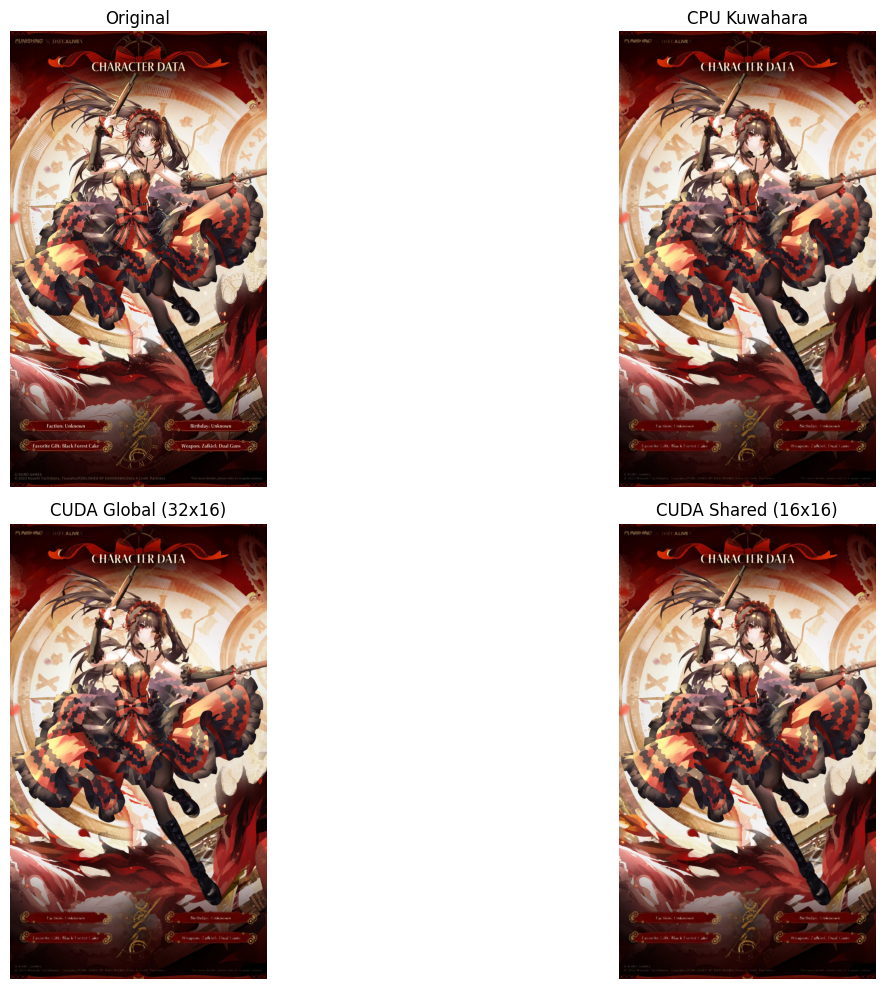


LABWORK 10 SUMMARY
Omega                         : 3
CPU time                      : 0.713460 s
Best global block size        : 32x16
Best global time              : 0.016328 s
Global speedup vs CPU         : 43.70x
Best shared block size        : 16x16
Best shared time              : 0.016187 s
Shared speedup vs CPU         : 44.08x
Shared speedup vs global      : 1.01x
Global max difference         : 0
Shared max difference         : 0

Results saved in:
/content/lab10_results


In [7]:
best_global_index = results_df["Global Time (s)"].idxmin()
best_shared_index = results_df["Shared Time (s)"].idxmin()

best_global_block_name = results_df.loc[best_global_index, "Block Size"]
best_shared_block_name = results_df.loc[best_shared_index, "Block Size"]
best_global_block = tuple(map(int, best_global_block_name.split("x")))
best_shared_block = tuple(map(int, best_shared_block_name.split("x")))
best_global_output = global_outputs[best_global_block]
best_shared_output = shared_outputs[best_shared_block]

cv2.imwrite(os.path.join(OUTPUT_DIR, "cpu_kuwahara.png"), cv2.cvtColor(cpu_output, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(OUTPUT_DIR, "gpu_global_kuwahara.png"), cv2.cvtColor(best_global_output, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(OUTPUT_DIR, "gpu_shared_kuwahara.png"), cv2.cvtColor(best_shared_output, cv2.COLOR_RGB2BGR))

global_difference = np.abs(best_global_output.astype(np.int16) - cpu_output.astype(np.int16)).astype(np.uint8)

shared_difference = np.abs(best_shared_output.astype(np.int16) - cpu_output.astype(np.int16)).astype(np.uint8)

cv2.imwrite(os.path.join(OUTPUT_DIR, "difference_global_cpu.png"), cv2.cvtColor(global_difference, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(OUTPUT_DIR, "difference_shared_cpu.png"), cv2.cvtColor(shared_difference, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cpu_output)
plt.title("CPU Kuwahara")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(best_global_output)
plt.title(f"CUDA Global ({best_global_block_name})")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(best_shared_output)
plt.title(f"CUDA Shared ({best_shared_block_name})")
plt.axis("off")

plt.tight_layout()

comparison_path = os.path.join(OUTPUT_DIR, "comparison.png")

plt.savefig(comparison_path, dpi=200, bbox_inches="tight")

plt.show()

best_global_time = results_df.loc[best_global_index, "Global Time (s)"]
best_shared_time = results_df.loc[best_shared_index, "Shared Time (s)"]

best_global_speedup = cpu_time / best_global_time
best_shared_speedup = cpu_time / best_shared_time
shared_vs_global = best_global_time / best_shared_time

global_max_diff = results_df.loc[best_global_index, "Global Max Diff"]

shared_max_diff = results_df.loc[best_shared_index, "Shared Max Diff"]

print()
print("=" * 70)
print("LABWORK 10 SUMMARY")
print("=" * 70)

print(f"Omega                         : {OMEGA}")

print(f"CPU time                      : {cpu_time:.6f} s")

print(
    f"Best global block size        : "
    f"{best_global_block_name}"
)

print(
    f"Best global time              : "
    f"{best_global_time:.6f} s"
)

print(
    f"Global speedup vs CPU         : "
    f"{best_global_speedup:.2f}x"
)

print(
    f"Best shared block size        : "
    f"{best_shared_block_name}"
)

print(
    f"Best shared time              : "
    f"{best_shared_time:.6f} s"
)

print(
    f"Shared speedup vs CPU         : "
    f"{best_shared_speedup:.2f}x"
)

print(
    f"Shared speedup vs global      : "
    f"{shared_vs_global:.2f}x"
)

print(f"Global max difference         : {global_max_diff}")
print(f"Shared max difference         : {shared_max_diff}")

print()
print("Results saved in:")
print(OUTPUT_DIR)